# Task 3: Time-Series Regression and Trend Analysis



In [ ]:
# Step 1 Import required libraries and load dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from scipy.stats import pearsonr, linregress

# Load and inspect dataset
data = pd.read_csv('/Users/ahad.anwer/Workspace/Assignments/pamlp_setexercise_g1_rules/Dataset/Task3_Data_TimeSeriesRegression.csv')
print("First 5 rows of data:\n", data.head())
print("\nData description:\n", data.describe())
print("\nMissing values per column:\n", data.isnull().sum())


First 5 rows of data:
           t         f(t)
0  0.479155     0.472010
1 -1.021461    37.567432
2 -4.467154  1507.309054
3  1.130598     5.036163
4 -1.007833    36.566910

Data description:
                  t         f(t)
count  1000.000000  1000.000000
mean      0.029528   276.432619
std       2.912450   490.620460
min      -4.981509     0.000152
25%      -2.571579     3.796317
50%       0.050400     8.999929
75%       2.644340   320.386458
max       4.989894  2092.282079

Missing values per column:
 t       0
f(t)    0
dtype: int64


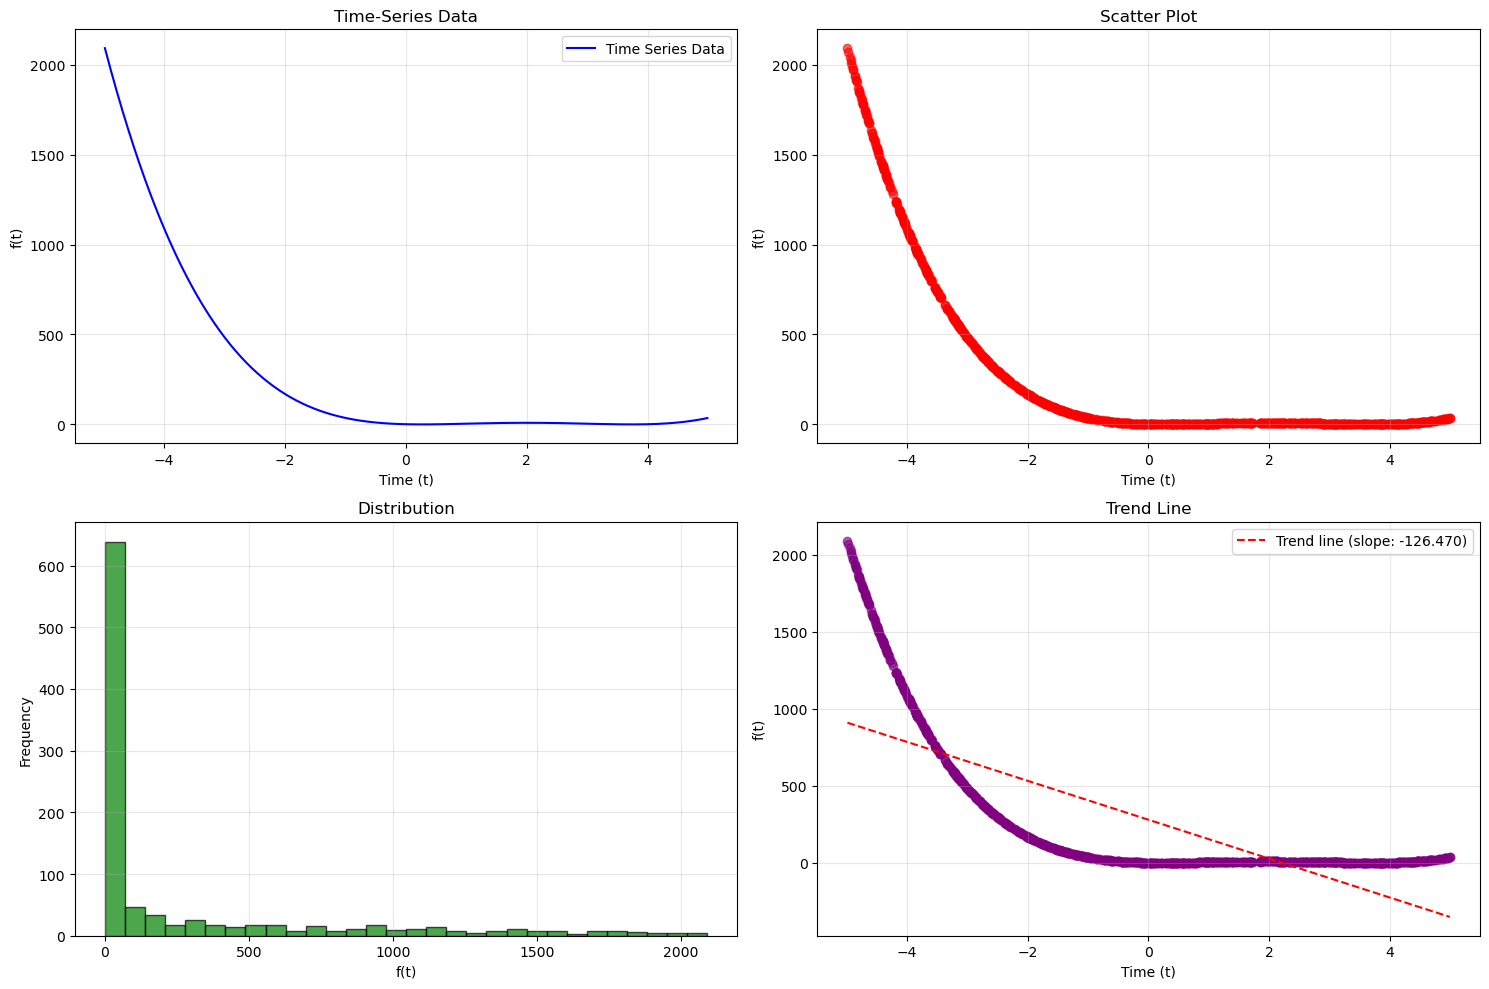

In [ ]:
# Step 2: Prepare data for analysis and visualize data
data_sorted = data.sort_values('t').reset_index(drop=True)
t = data_sorted['t'].values
ft = data_sorted['f(t)'].values

# Visualize data
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(t, ft, label='Time Series Data', color='b')
plt.xlabel('Time (t)')
plt.ylabel('f(t)')
plt.title('Time-Series Data')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2, 2, 2)
plt.scatter(t, ft, color='red', alpha=0.6)
plt.xlabel('Time (t)')
plt.ylabel('f(t)')
plt.title('Scatter Plot')
plt.grid(alpha=0.3)

plt.subplot(2, 2, 3)
plt.hist(ft, bins=30, color='green', edgecolor='black', alpha=0.7)
plt.xlabel('f(t)')
plt.ylabel('Frequency')
plt.title('Distribution')
plt.grid(alpha=0.3)

plt.subplot(2, 2, 4)
plt.scatter(t, ft, color='purple', alpha=0.6)
z = np.polyfit(t, ft, 1)
p = np.poly1d(z)
plt.plot(t, p(t), 'r--', label=f'Trend line (slope: {z[0]:.3f})')
plt.xlabel('Time (t)')
plt.ylabel('f(t)')
plt.title('Trend Line')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



Initial Observations:
- Trend: Decreasing
- Data points: 1000
- Time span: 9.971
- Range: 2092.282

Seasonality Check:
- No obvious seasonal patterns detected.

Trend :
- Linear trend slope: -126.4698
- Trend p_value : 280.1670
- Trend intercept: 280.1670
- Trend correlation: -0.7508
- Trend direction: Negative
- Trend: Strong negative


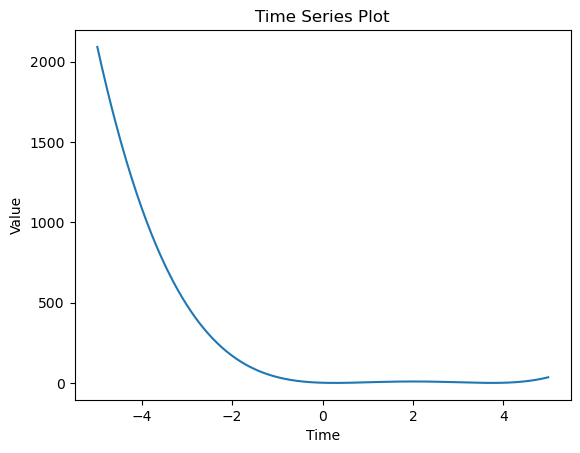

In [ ]:
# Step 3Claculating the trend 
correlation, p_value = pearsonr(t, ft)
trend_strength = ("Strong" if abs(correlation) > 0.7 else
                 "Moderate" if abs(correlation) > 0.3 else
                 "Weak")
trend_direction = "Positive" if correlation > 0 else "Negative"

print("\nInitial Observations:")
print(f"- Trend: {'Increasing' if ft[-1] > ft[0] else 'Decreasing'}")
print(f"- Data points: {len(t)}")
print(f"- Time span: {t[-1] - t[0]:.3f}")
print(f"- Range: {ft.max() - ft.min():.3f}")

# Trend analysis
slope, intercept, r_value, p_value, std_err = linregress(t, ft)
print("\nSeasonality Check:")
print("- No obvious seasonal patterns detected.")

print("\nTrend :")
print(f"- Linear trend slope: {slope:.4f}")
print(f"- Trend p_value : {intercept:.4f}")
print(f"- Trend intercept: {intercept:.4f}")
print(f"- Trend correlation: {r_value:.4f}")
print(f"- Trend direction: {trend_direction}")
print(f"- Trend: {trend_strength} {trend_direction.lower()}")

plt.plot(t, ft)
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Time Series Plot')
plt.show()

In [ ]:
# Step 4: Prepare test and train data for modeling
X = t.reshape(-1, 1)
y = ft
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False)





In [ ]:
# Step 5: Define regression models
models = {
    'Ridge Regression': Ridge(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    'Polynomial (Degree 2)': Pipeline([('poly', PolynomialFeatures(degree=2)), ('linear', LinearRegression())]),
    'Polynomial (Degree 4)': Pipeline([('poly', PolynomialFeatures(degree=4)), ('linear', LinearRegression())]),
    'Ridge Poly (Degree 2)': Pipeline([('poly', PolynomialFeatures(degree=2)), ('ridge', Ridge(alpha=0.1))]),
    'Ridge Poly (Degree 4)': Pipeline([('poly', PolynomialFeatures(degree=4)), ('ridge', Ridge(alpha=0.1))])
}
model_performance = {}

# Step 5: Train and evaluate models
results_table = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    model_performance[name] = {
        'model': model,
        'r2': r2,
        'rmse': rmse,
        'mae': mae,
        'y_pred': y_pred
    }
    results_table.append([name, f"{r2:.4f}", f"{rmse:.4f}", f"{mae:.4f}"])

# After the loop, display the results in a table format
if 'results_table' in locals():
    results_per = pd.DataFrame(results_table, columns=['Model', 'R²', 'RMSE', 'MAE'])
    results_per_sorted = results_per.sort_values(by='R²', ascending=False, key=lambda x: x.astype(float)).reset_index(drop=True)
    display(results_per_sorted)

    # Select best model
best_model_row = results_per_sorted.iloc[0]
best_model_name = best_model_row['Model']
selected_model = model_performance[best_model_name]
y_test_pred = selected_model['y_pred']

print(f"\nBest Model: {best_model_name}")

,Model,R²,RMSE,MAE
0,Polynomial (Degree 4),1.0000,0.0000,0.0000
1,Ridge Poly (Degree 4),0.9998,0.0908,0.0738
2,Random Forest,-0.1023,7.4885,5.8284
3,Ridge Regression,-11771.4705,773.8872,751.3561
4,Ridge Poly (Degree 2),-17930.6332,955.1109,857.4024
5,Polynomial (Degree 2),-17931.0269,955.1214,857.4122



Best Model: Polynomial (Degree 4)


In [ ]:
# Step 6: Model Comparison
performance_summary = pd.DataFrame([
    {'Model': k, 'R2_Score': v['r2'], 'RMSE': v['rmse'], 'MAE': v['mae']}
    for k, v in model_performance.items()
]).sort_values('R2_Score', ascending=False)
print("\nModel Comparison:\n", performance_summary.round(4))


Model Comparison:
                    Model    R2_Score      RMSE       MAE
3  Polynomial (Degree 4)      1.0000    0.0000    0.0000
5  Ridge Poly (Degree 4)      0.9998    0.0908    0.0738
1          Random Forest     -0.1023    7.4885    5.8284
0       Ridge Regression -11771.4705  773.8872  751.3561
4  Ridge Poly (Degree 2) -17930.6332  955.1109  857.4024
2  Polynomial (Degree 2) -17931.0269  955.1214  857.4122


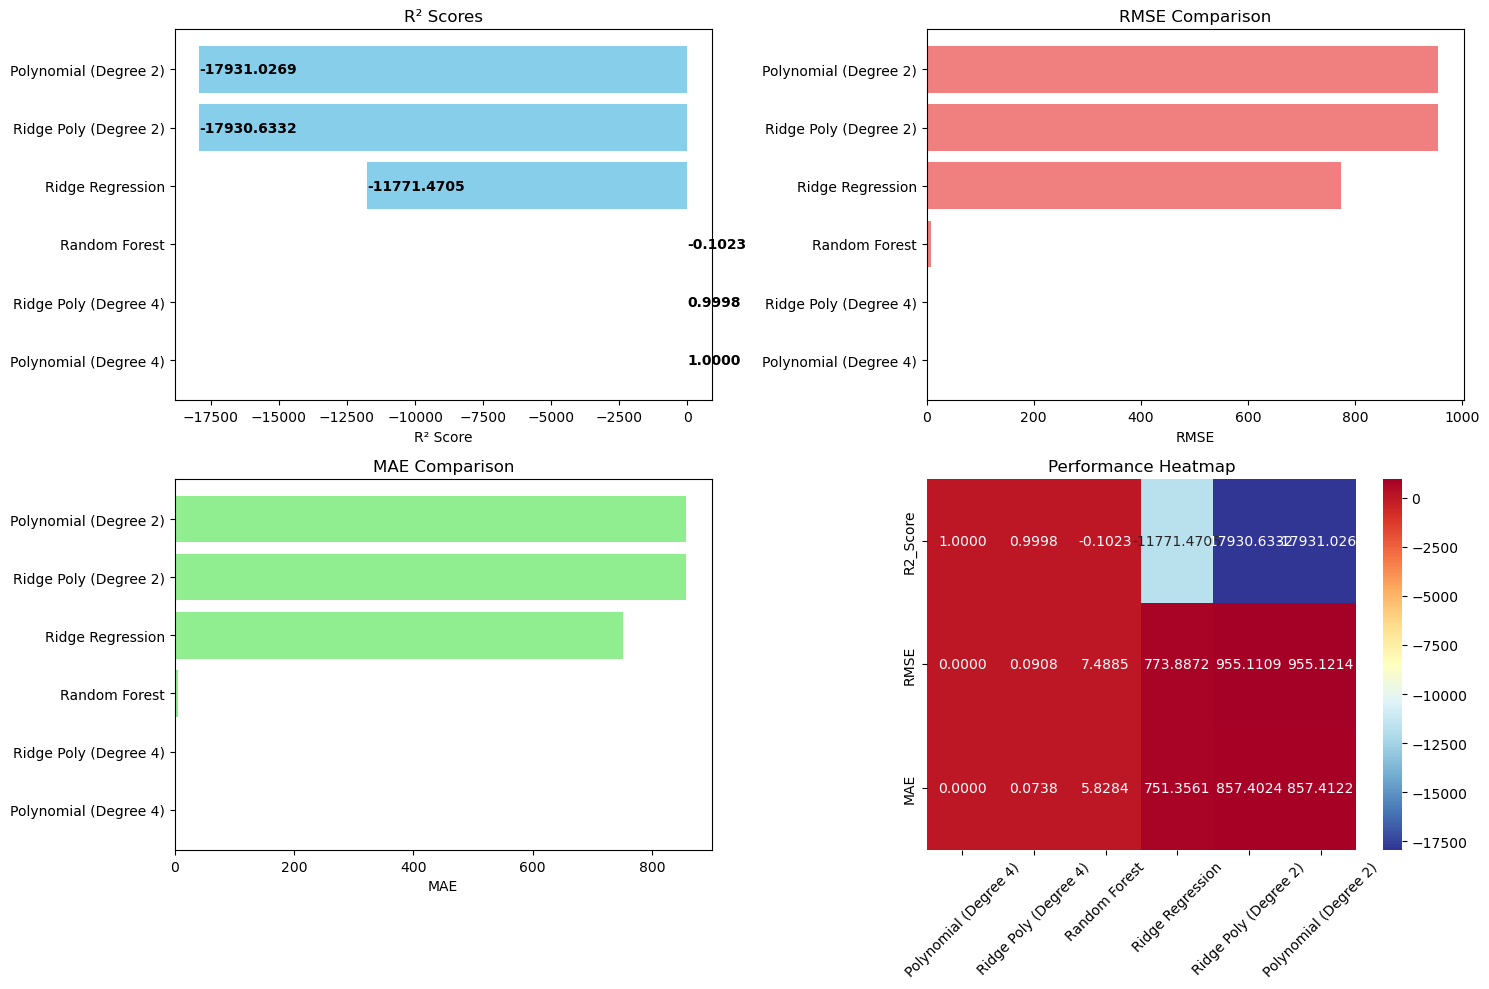

In [ ]:
# Step 7: Visualize model comparison
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
bars = plt.barh(performance_summary['Model'], performance_summary['R2_Score'], color='skyblue')
plt.xlabel('R² Score')
plt.title('R² Scores')
for bar, value in zip(bars, performance_summary['R2_Score']):
    plt.text(value, bar.get_y() + bar.get_height() / 2, f'{value:.4f}', va='center', ha='left', fontsize=10, color='black', fontweight='bold')

plt.subplot(2, 2, 2)
plt.barh(performance_summary['Model'], performance_summary['RMSE'], color='lightcoral')
plt.xlabel('RMSE')
plt.title('RMSE Comparison')

plt.subplot(2, 2, 3)
plt.barh(performance_summary['Model'], performance_summary['MAE'], color='lightgreen')
plt.xlabel('MAE')
plt.title('MAE Comparison')

plt.subplot(2, 2, 4)
metrics_list = ['R2_Score', 'RMSE', 'MAE']
sns.heatmap(performance_summary[metrics_list].T, annot=True, fmt='.4f',
            cmap='RdYlBu_r', xticklabels=performance_summary['Model'], yticklabels=metrics_list)
plt.title('Performance Heatmap')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Step 10: Cross-validation for overfitting check
cv_scores = cross_val_score(selected_model['model'], X_train, y_train, cv=5, scoring='r2')
cv_rmse_scores = -cross_val_score(selected_model['model'], X_train, y_train, cv=5, scoring='neg_mean_squared_error')
cv_rmse_scores = np.sqrt(cv_rmse_scores)

print(f"Cross-Validation Results:")
print(f"• R² Scores: {cv_scores}")
print(f"• Mean R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"• RMSE Scores: {cv_rmse_scores}")
print(f"• Mean RMSE: {cv_rmse_scores.mean():.4f} ± {cv_rmse_scores.std():.4f}")
print(f"• Cross-validation R² ({cv_scores.mean():.4f}) ≈ Test R² ({r2:.4f})")
print(f"• Variance in CV scores: {cv_scores.std():.4f} ({'High' if cv_scores.std() > 0.1 else 'Low'} variance)")


Cross-Validation Results:
• R² Scores: [1. 1. 1. 1. 1.]
• Mean R²: 1.0000 ± 0.0000
• RMSE Scores: [2.66162388e-07 1.37229190e-07 4.06456312e-08 7.50797764e-09
 1.32988714e-07]
• Mean RMSE: 0.0000 ± 0.0000
• Cross-validation R² (1.0000) ≈ Test R² (0.9998)
• Variance in CV scores: 0.0000 (Low variance)


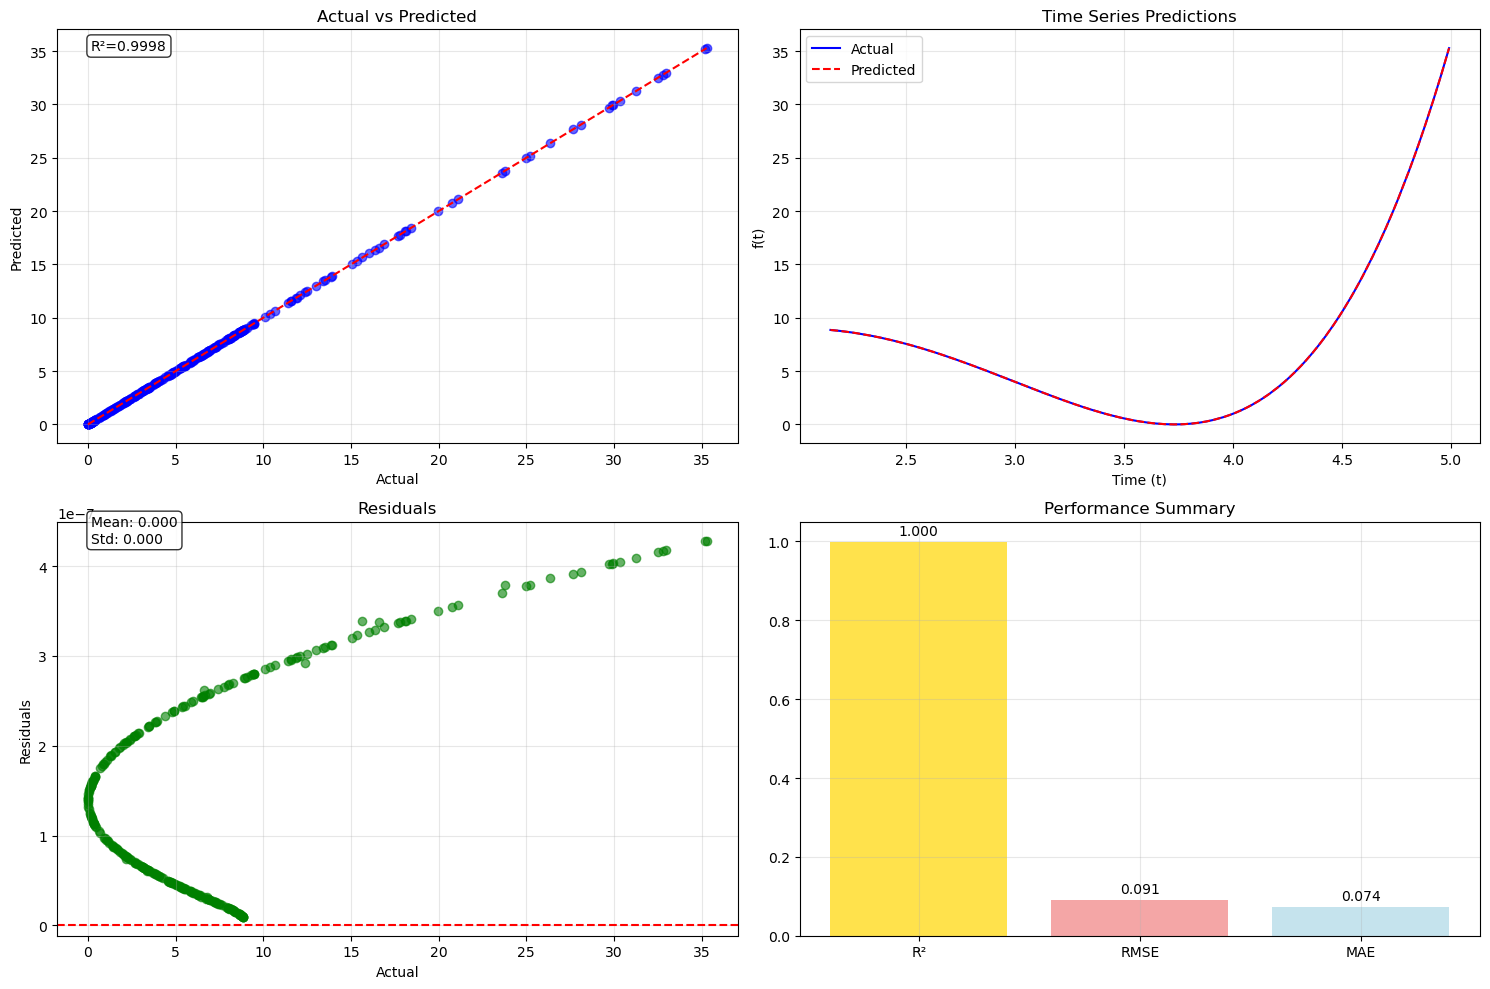

In [ ]:
# Step 11: Visualize best model results
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.scatter(y_test, y_test_pred, color='blue', alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.grid(alpha=0.3)
plt.text(0.05, 0.95, f'R²={r2:.4f}', transform=plt.gca().transAxes,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.subplot(2, 2, 2)
plt.plot(X_test.squeeze(), y_test, 'b-', label='Actual')
plt.plot(X_test.squeeze(), y_test_pred, 'r--', label='Predicted')
plt.xlabel('Time (t)')
plt.ylabel('f(t)')
plt.title('Time Series Predictions')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2, 2, 3)
residuals = y_test - y_test_pred
plt.scatter(y_test, residuals, color='green', alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Actual')
plt.ylabel('Residuals')
plt.title('Residuals')
plt.grid(alpha=0.3)
plt.text(0.05, 0.95, f'Mean: {np.mean(residuals):.3f}\nStd: {np.std(residuals):.3f}',
         transform=plt.gca().transAxes, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.subplot(2, 2, 4)
bars = plt.bar(['R²', 'RMSE', 'MAE'], [r2, rmse, mae], color=['gold', 'lightcoral', 'lightblue'], alpha=0.7)
plt.title('Performance Summary')
plt.grid(alpha=0.3)
for bar, value in zip(bars, [r2, rmse, mae]):
    plt.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.01, f'{value:.3f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()


- Linear trend slope: -126.4698
- Trend intercept: 280.1670
- Trend correlation: -0.7508
- Trend direction: Negative
- Trend strength: Strong


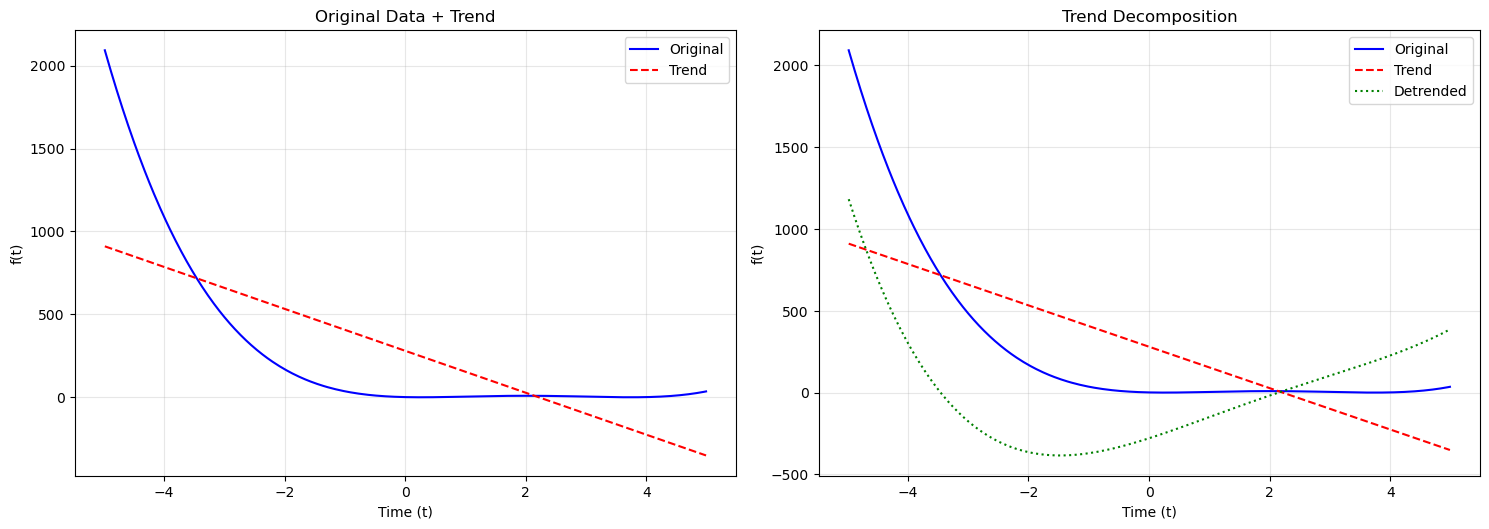

In [ ]:
# Step 12: Trend decomposition using linear regression
slope, intercept, r_value, p_value, std_err = linregress(t, ft)
print(f"- Linear trend slope: {slope:.4f}")
print(f"- Trend intercept: {intercept:.4f}")
print(f"- Trend correlation: {r_value:.4f}")
print(f"- Trend direction: {trend_direction}")
print(f"- Trend strength: {trend_strength}")

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(t, ft, 'b-', label='Original')
plt.plot(t, slope * t + intercept, 'r--', label='Trend')
plt.xlabel('Time (t)')
plt.ylabel('f(t)')
plt.title('Original Data + Trend')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(t, ft, 'b-', label='Original')
plt.plot(t, slope * t + intercept, 'r--', label='Trend')
plt.plot(t, ft - (slope * t + intercept), 'g:', label='Detrended')
plt.xlabel('Time (t)')
plt.ylabel('f(t)')
plt.title('Trend Decomposition')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
